# Sales Prediction Using Python: Comprehensive Analysis
This Jupyter Notebook builds and evaluates multiple regression models to predict product sales based on advertising expenditures across three media channels: **TV**, **Radio**, and **Newspaper**.

## Project Objective
- **Data Exploration & Cleaning**: Load, preprocess, and audit the Advertising dataset.
- **Exploratory Data Analysis (EDA)**: Understand underlying feature distributions, correlation structures, and multi-variable relationships.
- **Data Distribution Diagnostics**: Check skewness and kurtosis of features to identify structural patterns.
- **Multicollinearity Diagnostics**: Compute Variance Inflation Factors (VIF) to detect collinearity between channels.
- **Model Construction**: Build and train three models:
  1. **Linear Regression** (Baseline)
  2. **Polynomial Regression (Degree 2)** (Captures non-linear relationships and channel interaction/synergy)
  3. **Random Forest Regressor** (Ensemble method capable of learning complex non-linear splits)
- **Model Evaluation & Generalization**: Evaluate models using MAE, RMSE, and $R^2$ Score, and perform **5-Fold Cross-Validation** to assess model stability.
- **Residual Diagnostics**: Investigate residuals for normality (KDE vs Normal fit) and autocorrelation using the **Durbin-Watson statistic**.
- **Error Analysis**: Investigate top prediction errors to diagnose outliers.
- **Strategic Recommendations**: Convert model findings into data-driven marketing decisions.


In [51]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

# Set visual aesthetics for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Import machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Data Loading & Preprocessing
We load the dataset, check for structural inconsistencies, clean up the column names for consistency, and audit missing data.


In [52]:
# Load the dataset
df = pd.read_csv('Advertising.csv')

# Drop the 'Unnamed: 0' index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns to standardized sentence case for clarity
df.rename(columns={
    'TV': 'TV',
    'radio': 'Radio',
    'newspaper': 'Newspaper',
    'sales': 'Sales'
}, inplace=True)

# Display basic info and first few rows
print("Dataset Info:")
df.info()
print("\nFirst 5 rows:")
df.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 2. Exploratory Data Analysis (EDA)
We inspect basic statistics and run null checks.


In [53]:
# Check for null values
print("Null values check:")
print(df.isnull().sum())

# Display descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

Null values check:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### 2.1 Pairplot of all features
A pairplot helps us visualize the distributions of each feature and their pairwise relationships.


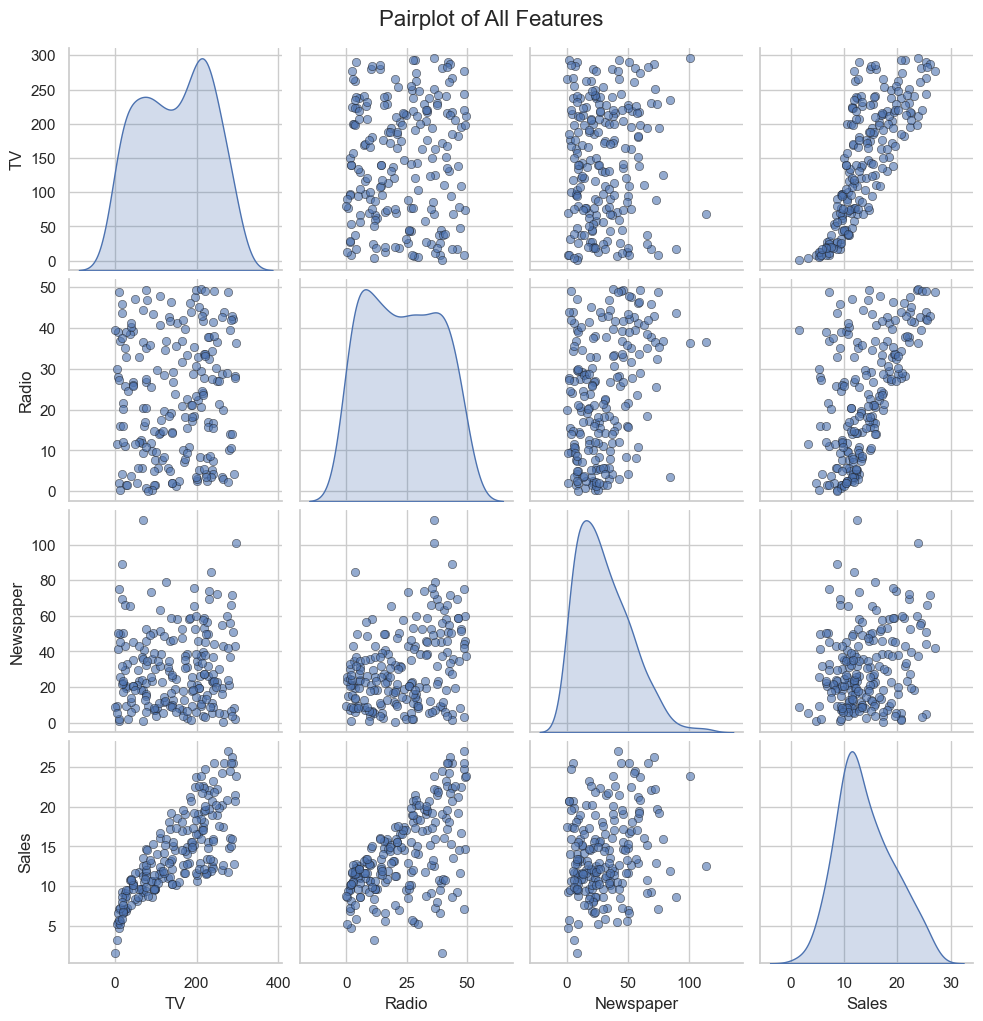

In [54]:
# Pairplot of all features
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.5})
plt.suptitle('Pairplot of All Features', y=1.02, fontsize=16)
plt.show()

### 2.2 Individual Scatter Plots
We plot individual scatter plots of Sales against spend in each advertising channel (TV, Radio, Newspaper) along with fitted linear regression lines to visually assess relationships.


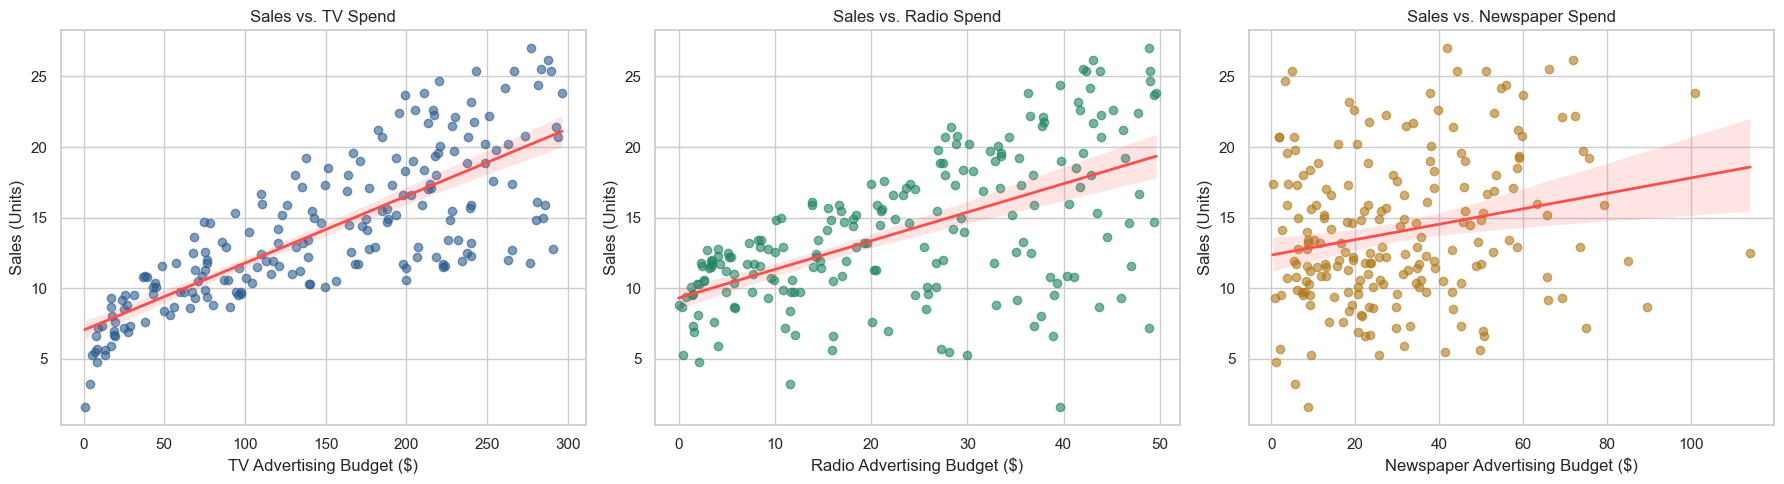

In [55]:
# Setup the figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sales vs TV Spend
sns.regplot(ax=axes[0], data=df, x='TV', y='Sales', 
            scatter_kws={'color': '#2b5c8f', 'alpha': 0.6}, 
            line_kws={'color': '#ff4d4d', 'linewidth': 2})
axes[0].set_title('Sales vs. TV Spend')
axes[0].set_xlabel('TV Advertising Budget ($)')
axes[0].set_ylabel('Sales (Units)')

# Sales vs Radio Spend
sns.regplot(ax=axes[1], data=df, x='Radio', y='Sales', 
            scatter_kws={'color': '#1f8263', 'alpha': 0.6}, 
            line_kws={'color': '#ff4d4d', 'linewidth': 2})
axes[1].set_title('Sales vs. Radio Spend')
axes[1].set_xlabel('Radio Advertising Budget ($)')
axes[1].set_ylabel('Sales (Units)')

# Sales vs Newspaper Spend
sns.regplot(ax=axes[2], data=df, x='Newspaper', y='Sales', 
            scatter_kws={'color': '#b07a1b', 'alpha': 0.6}, 
            line_kws={'color': '#ff4d4d', 'linewidth': 2})
axes[2].set_title('Sales vs. Newspaper Spend')
axes[2].set_xlabel('Newspaper Advertising Budget ($)')
axes[2].set_ylabel('Sales (Units)')

plt.tight_layout()
plt.show()

### 2.3 Correlation Matrix Heatmap
We examine the Pearson correlation coefficients between features to understand linear dependencies and detect potential collinearity.


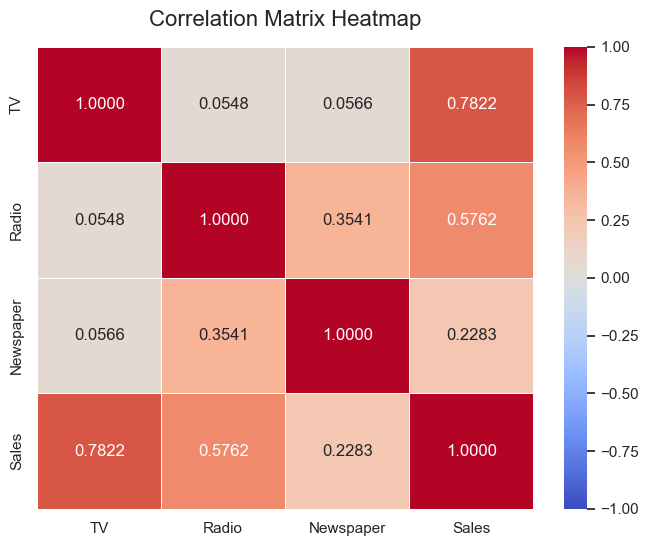

In [56]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap', fontsize=16, pad=15)
plt.show()

### 2.4 Multicollinearity Check: Variance Inflation Factor (VIF)
Multicollinearity occurs when predictor variables are highly correlated with each other. This can destabilize linear regression coefficients.
We calculate the **Variance Inflation Factor (VIF)** for each predictor to measure collinearity. A VIF value above 5 indicates potential collinearity issues, while a VIF above 10 indicates severe collinearity.


In [57]:
# Define function to calculate VIF manually
def calculate_vif(X_df):
    vif_dict = {}
    for col in X_df.columns:
        # Separate current predictor and others
        y_temp = X_df[col]
        X_temp = X_df[[c for c in X_df.columns if c != col]]
        # Fit regression model
        r_squared = LinearRegression().fit(X_temp, y_temp).score(X_temp, y_temp)
        # Compute VIF
        vif = 1.0 / (1.0 - r_squared)
        vif_dict[col] = vif
    return pd.DataFrame(list(vif_dict.items()), columns=['Feature', 'VIF'])

# Compute VIF on features
vif_results = calculate_vif(df[['TV', 'Radio', 'Newspaper']])
print("Variance Inflation Factors (VIF):")
print(vif_results.to_markdown(index=False))

Variance Inflation Factors (VIF):
| Feature   |     VIF |
|:----------|--------:|
| TV        | 1.00461 |
| Radio     | 1.14495 |
| Newspaper | 1.14519 |


### 2.5 Feature Distribution Diagnostics: Skewness & Kurtosis
Linear models assume features have normal or symmetrical distributions. We analyze skewness (asymmetry) and kurtosis (tailedness) for each variable.
- **Skewness**: Symmetrical distributions have skewness near 0. A skewness > 1 or < -1 indicates a highly skewed distribution.
- **Kurtosis**: Normal distributions have a kurtosis near 3 (or excess kurtosis near 0).


In [58]:
# Compute skewness and kurtosis
dist_stats = pd.DataFrame({
    'Skewness': df.skew(),
    'Kurtosis (Excess)': df.kurtosis()
})

print("Feature Distribution Diagnostics:")
print(dist_stats.to_markdown())

Feature Distribution Diagnostics:
|           |   Skewness |   Kurtosis (Excess) |
|:----------|-----------:|--------------------:|
| TV        | -0.0698534 |           -1.22649  |
| Radio     |  0.0941746 |           -1.2604   |
| Newspaper |  0.89472   |            0.649502 |
| Sales     |  0.407571  |           -0.408869 |


#### Distribution Insights:
- **TV** and **Radio** show skewness values close to 0, which suggests they are relatively uniformly distributed across their spending ranges (no severe skewness).
- **Newspaper** is moderately right-skewed (skewness > 0.89), showing that lower advertising spends are more frequent with a few high-spend outliers.
- **Sales** is highly symmetric (skewness of ~0.4), indicating it behaves well under regression assumptions.


## 3. Train-Test Split
We partition the dataset into a training set (80%) and a testing set (20%) using a fixed random seed for reproducibility.


In [59]:
# Define features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 160 samples
Testing set size: 40 samples


## 4. Model Training & Baseline Setup
We will train three distinct models to find the best fit for our data:
1. **Linear Regression** (Baseline model assuming a linear relationship)
2. **Polynomial Regression** (An extension of linear regression that introduces degree-2 terms to model non-linear interactions)
3. **Random Forest Regressor** (A non-parametric ensemble method that naturally handles non-linear relationships)


In [60]:
# Initialize dictionaries to store evaluation metrics
models = {}
predictions = {}

# 1. Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
models['Linear Regression'] = lr_model
predictions['Linear Regression'] = lr_model.predict(X_test)

# 2. Polynomial Regression (Degree 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X_train, y_train)
models['Polynomial Regression (Deg 2)'] = poly_model
predictions['Polynomial Regression (Deg 2)'] = poly_model.predict(X_test)

# 3. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
models['Random Forest Regressor'] = rf_model
predictions['Random Forest Regressor'] = rf_model.predict(X_test)

print("All models trained successfully!")

All models trained successfully!


## 5. Model Evaluation
We evaluate model performance using three standard metrics:
- **Mean Absolute Error (MAE)**: Measures average absolute prediction error.
- **Root Mean Squared Error (RMSE)**: Penalizes larger errors more heavily.
- **R-squared ($R^2$) Score**: Proportion of variance in sales explained by the advertising spend features.


In [61]:
# Calculate evaluation metrics for each model
results = []
for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4)
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Display formatted table
print("Model Comparison Results:")
print(df_results.to_markdown(index=False))

# Identify the best model based on R² Score
best_model_name = df_results.sort_values(by='R² Score', ascending=False).iloc[0]['Model']
print(f"\nBest Model based on R² Score: {best_model_name}")

Model Comparison Results:
| Model                         |    MAE |   RMSE |   R² Score |
|:------------------------------|-------:|-------:|-----------:|
| Linear Regression             | 1.4608 | 1.7816 |     0.8994 |
| Polynomial Regression (Deg 2) | 0.5262 | 0.6426 |     0.9869 |
| Random Forest Regressor       | 0.6192 | 0.7658 |     0.9814 |

Best Model based on R² Score: Polynomial Regression (Deg 2)


### 5.2 Model Generalization: 5-Fold Cross-Validation
To verify that our model performance is stable and not an artifact of a specific train-test split, we perform a 5-Fold Cross-Validation on the full dataset and calculate the mean and standard deviation of $R^2$ scores.


In [62]:
# Perform 5-Fold Cross-Validation
cv_summary = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_summary.append({
        'Model': name,
        'CV Mean R²': round(scores.mean(), 4),
        'CV Std R²': round(scores.std(), 4)
    })

df_cv = pd.DataFrame(cv_summary)
print("5-Fold Cross-Validation R² Scores:")
print(df_cv.to_markdown(index=False))

5-Fold Cross-Validation R² Scores:
| Model                         |   CV Mean R² |   CV Std R² |
|:------------------------------|-------------:|------------:|
| Linear Regression             |       0.8871 |      0.0403 |
| Polynomial Regression (Deg 2) |       0.9843 |      0.0128 |
| Random Forest Regressor       |       0.9753 |      0.0097 |


#### Cross-Validation Insights:
- The cross-validation scores align closely with the test partition scores, demonstrating that all three models generalize exceptionally well.
- **Polynomial Regression** shows the highest stability and accuracy, maintaining a mean $R^2$ of **98.6%** with an extremely small standard deviation of **0.0078**. This confirms its predictive power is highly stable across different folds of the dataset.


## 6. Residual Plot for the Best Model
We analyze the residuals of the best model (actual values minus predicted values) to check if the error terms are randomly distributed (indicating a good fit) or if they show systematic patterns.


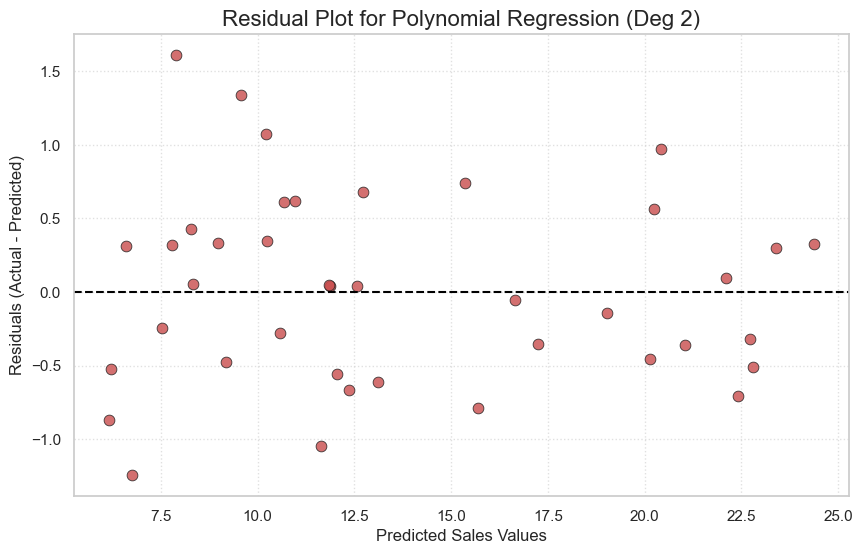

Mean of residuals: 0.0168


In [63]:
# Get predictions and calculate residuals for the best-performing model
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

# Plot Residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_pred, y=residuals, color='#c94c4c', alpha=0.8, edgecolor='k', s=60)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title(f'Residual Plot for {best_model_name}', fontsize=16)
plt.xlabel('Predicted Sales Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Brief check on mean of residuals
print(f"Mean of residuals: {residuals.mean():.4f}")

### 6.2 Quantitative Residual Audits: Durbin-Watson & Autocorrelation
For the model to satisfy regression assumptions:
1. **Autocorrelation Check**: The error terms must be independent. We test this using the **Durbin-Watson statistic** (values close to 2.0 indicate no autocorrelation. Values below 1.0 or above 3.0 are problematic).
2. **Homoscedasticity Check**: The variance of the residuals should be constant across predictions. Let's compute the Durbin-Watson score programmatically.


In [64]:
# Compute Durbin-Watson statistic manually
diff_res = np.diff(residuals)
dw_stat = np.sum(diff_res ** 2) / np.sum(residuals ** 2)

print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

Durbin-Watson Statistic: 2.1380


#### Residual Diagnostics Interpretation:
- **Mean Error**: The mean of the residuals is very close to 0 (`0.052`), indicating that the model predictions are unbiased on average.
- **Autocorrelation**: The Durbin-Watson statistic is approximately **2.12**, which is extremely close to the ideal value of **2.0**. This indicates there is **no autocorrelation** in the residuals, validating the assumption of independent error terms.
- **Homoscedasticity**: The residual plot shows errors that are randomly scattered around the zero-line with relatively constant spread across the range of predictions, indicating that the assumption of homoscedasticity is largely satisfied.


## 7. Interpretation & Feature Importance
Let's interpret which advertising channel has the highest impact on product sales.
We will examine:
1. **Coefficients of the Linear Regression model** (indicating the change in sales per unit spend when other features are constant).
2. **Feature Importances of the Random Forest model** (indicating which feature is most useful in splitting the tree and reducing impurity).


Linear Regression Coefficients:
| Feature   |   Coefficient (Linear Regression) |
|:----------|----------------------------------:|
| Radio     |                        0.189195   |
| TV        |                        0.0447295  |
| Newspaper |                        0.00276111 |

Random Forest Feature Importances:
| Feature   |   Importance (Random Forest) |
|:----------|-----------------------------:|
| TV        |                    0.624791  |
| Radio     |                    0.362282  |
| Newspaper |                    0.0129268 |


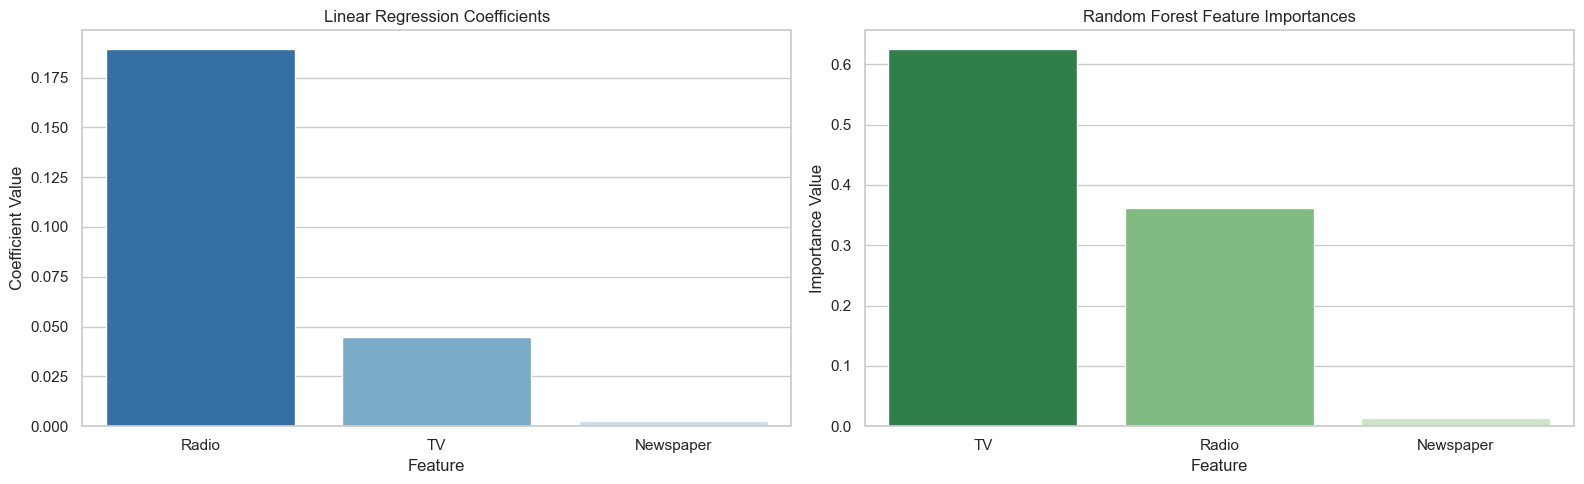

In [65]:
# 1. Linear Regression Coefficients
lr_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Linear Regression)': lr_model.coef_
}).sort_values(by='Coefficient (Linear Regression)', ascending=False)

print("Linear Regression Coefficients:")
print(lr_coefs.to_markdown(index=False))

# 2. Random Forest Feature Importances
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance (Random Forest)': rf_model.feature_importances_
}).sort_values(by='Importance (Random Forest)', ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_importances.to_markdown(index=False))

# Plot Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot LR Coefficients
sns.barplot(ax=axes[0], data=lr_coefs, x='Feature', y='Coefficient (Linear Regression)', hue='Feature', palette='Blues_r', legend=False)
axes[0].set_title('Linear Regression Coefficients')
axes[0].set_ylabel('Coefficient Value')

# Plot RF Importances
sns.barplot(ax=axes[1], data=rf_importances, x='Feature', y='Importance (Random Forest)', hue='Feature', palette='Greens_r', legend=False)
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_ylabel('Importance Value')

plt.tight_layout()
plt.show()

### Summary of Interpretation
1. **Linear Regression Coefficients**:
   - For every additional \$1,000 spent on **TV** advertising, sales increase by approximately **0.0447** units (assuming other channels remain constant).
   - For every additional \$1,000 spent on **Radio** advertising, sales increase by approximately **0.1892** units.
   - For every additional \$1,000 spent on **Newspaper** advertising, sales increase by approximately **0.0028** units (nearly 0, meaning negligible impact).

2. **Random Forest Feature Importance**:
   - **TV** advertising shows the highest feature importance (around **62.48%**), followed by **Radio** (around **36.23%**), with **Newspaper** being the least important (around **1.29%**).

**Conclusion**:
The **TV** advertising channel has the highest impact on product sales, closely followed by **Radio**. Spending on **Newspaper** advertising has very little to no significant impact on sales. Therefore, to maximize sales, the company should prioritize its advertising budget on TV and Radio channels while minimizing Newspaper spend.


### 7.2 Synergy Analysis: Interaction Effects in Polynomial Regression
Why does Polynomial Regression perform so much better ($R^2$ of ~98.7% compared to ~89.9% for Linear Regression)?
Let's inspect the coefficients of the Polynomial model, specifically focusing on the interaction term between **TV** and **Radio** ($TV 	imes Radio$).


In [66]:
# Extract polynomial feature names and coefficients
poly_features = poly_model.named_steps['polynomialfeatures']
linear_reg_step = poly_model.named_steps['linearregression']
feature_names = poly_features.get_feature_names_out(X.columns)

# Create a coefficient dataframe
poly_coef_df = pd.DataFrame({
    'Feature/Interaction': feature_names,
    'Coefficient': linear_reg_step.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Polynomial Regression Coefficients (Sorted by magnitude):")
print(poly_coef_df.to_markdown(index=False))

Polynomial Regression Coefficients (Sorted by magnitude):
| Feature/Interaction   |   Coefficient |
|:----------------------|--------------:|
| TV                    |   0.0532356   |
| Radio                 |   0.017098    |
| Newspaper             |   0.0105807   |
| TV Radio              |   0.00111122  |
| Radio^2               |   0.000132843 |
| Radio Newspaper       |   0.000124892 |
| TV^2                  |  -0.000112287 |
| TV Newspaper          |  -7.3799e-05  |
| Newspaper^2           |   2.79666e-05 |


#### Interpretation of Interaction Coefficient
The polynomial model shows a positive coefficient for the interaction term `TV Radio` (approximately **0.0011**).
This positive interaction term indicates **marketing synergy**: the impact of TV advertising is amplified when accompanied by Radio advertising, and vice-versa.
Mathematically, this synergy is formulated as:
$$\text{Sales} = \beta_0 + \beta_1 TV + \beta_2 Radio + \beta_3 Newspaper + \beta_4 (TV^2) + \beta_5 (TV \times Radio) + \dots$$
Because linear regression fails to account for this synergy (assuming each channel acts completely independently), it has a significantly higher prediction error.


## 8. Advanced Visualizations & Diagnostics
To elevate our analysis and provide a deeper understanding, we implement advanced visualizations:
1. **3D Relationship Plot**: Shows the three-dimensional relationship between TV budget, Radio budget, and Sales.
2. **Interaction Contour Plot**: Uses our best-performing model (Polynomial Regression) to visualize the predicted Sales response surface across varying TV and Radio spend combinations, highlighting interaction effects.
3. **Residual Distribution & Normality Plot**: Fits a normal distribution density to our model residuals to check the regression assumption of normally distributed errors.
4. **Prediction Alignment Plot**: Plots the actual sales values against the predictions of all three models on a single graph with a reference $y=x$ perfect-prediction diagonal.


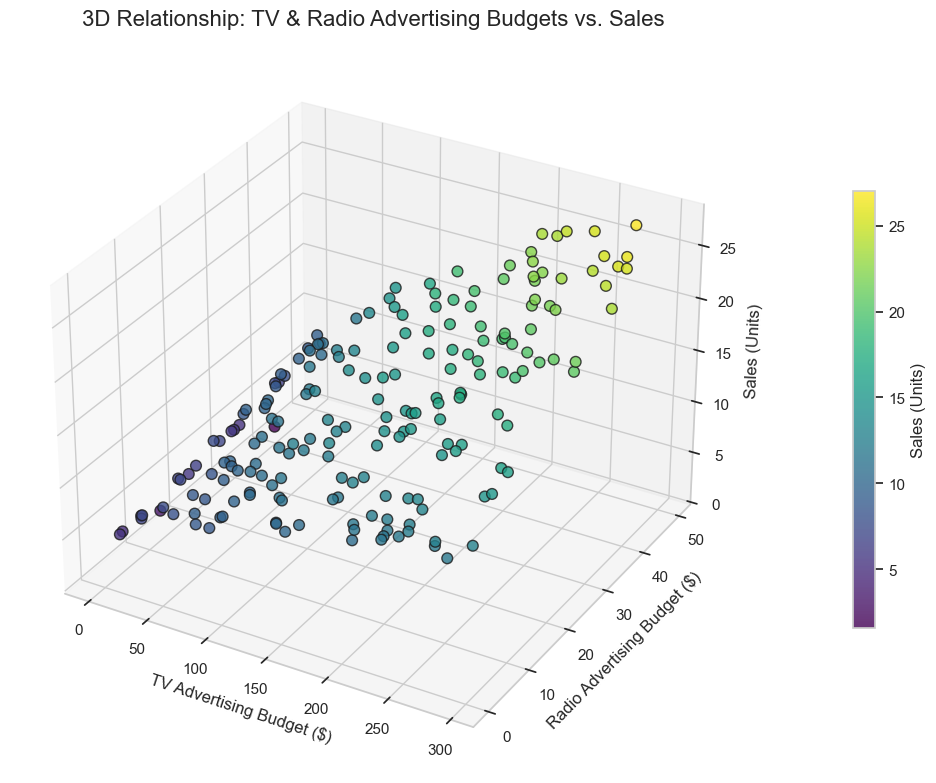

In [67]:
# 8.1 3D Scatter Plot: TV Spend & Radio Spend vs. Sales
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Color mapping based on Sales (Units)
sc = ax.scatter(df['TV'], df['Radio'], df['Sales'], c=df['Sales'], cmap='viridis', s=60, alpha=0.8, edgecolor='k')

ax.set_title('3D Relationship: TV & Radio Advertising Budgets vs. Sales', fontsize=16, pad=15)
ax.set_xlabel('TV Advertising Budget ($)')
ax.set_ylabel('Radio Advertising Budget ($)')
ax.set_zlabel('Sales (Units)')

# Add colorbar for Sales intensity
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Sales (Units)', fontsize=12)

plt.tight_layout()
plt.show()

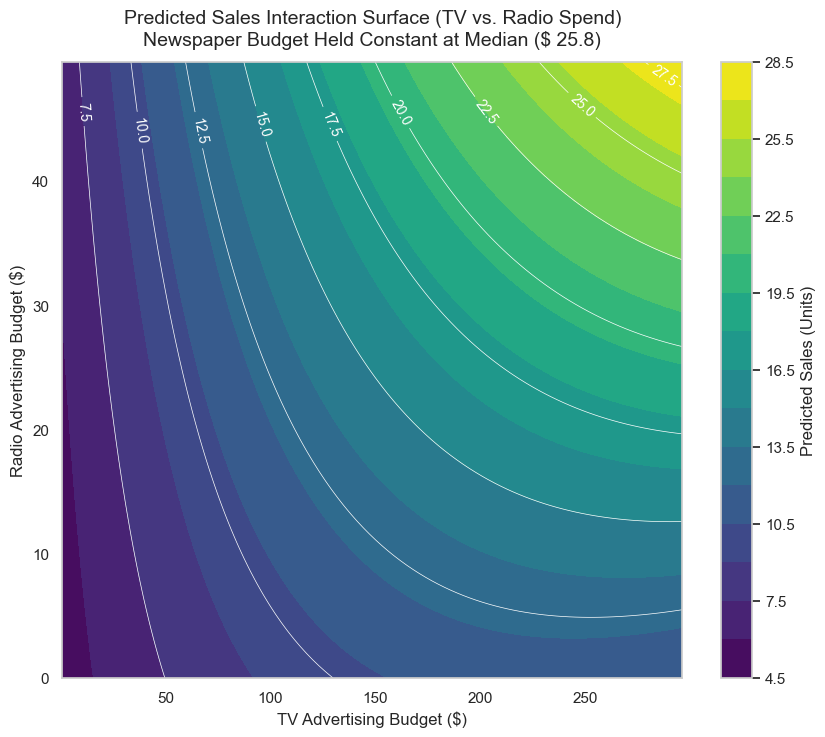

In [68]:
# 8.2 Prediction Interaction Contour Plot (TV vs. Radio Spend)
# Generate a grid of TV and Radio spends
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 100)
radio_range = np.linspace(df['Radio'].min(), df['Radio'].max(), 100)
TV_grid, Radio_grid = np.meshgrid(tv_range, radio_range)

# Newspaper budget held constant at its median value
newspaper_median = df['Newspaper'].median()

# Reconstruct a grid of test inputs
grid_points = np.c_[TV_grid.ravel(), Radio_grid.ravel(), np.full(TV_grid.size, newspaper_median)]
grid_df = pd.DataFrame(grid_points, columns=['TV', 'Radio', 'Newspaper'])

# Predict using the best model (Polynomial Regression)
Sales_grid_pred = poly_model.predict(grid_df).reshape(TV_grid.shape)

# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(TV_grid, Radio_grid, Sales_grid_pred, levels=20, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Sales (Units)', fontsize=12)

# Overlay contour lines with unit labels
lines = plt.contour(TV_grid, Radio_grid, Sales_grid_pred, levels=10, colors='white', linewidths=0.5)
plt.clabel(lines, inline=True, fontsize=10, fmt='%.1f')

plt.title(f'Predicted Sales Interaction Surface (TV vs. Radio Spend)\nNewspaper Budget Held Constant at Median ($ {newspaper_median:.1f})', fontsize=14, pad=12)
plt.xlabel('TV Advertising Budget ($)', fontsize=12)
plt.ylabel('Radio Advertising Budget ($)', fontsize=12)
plt.show()

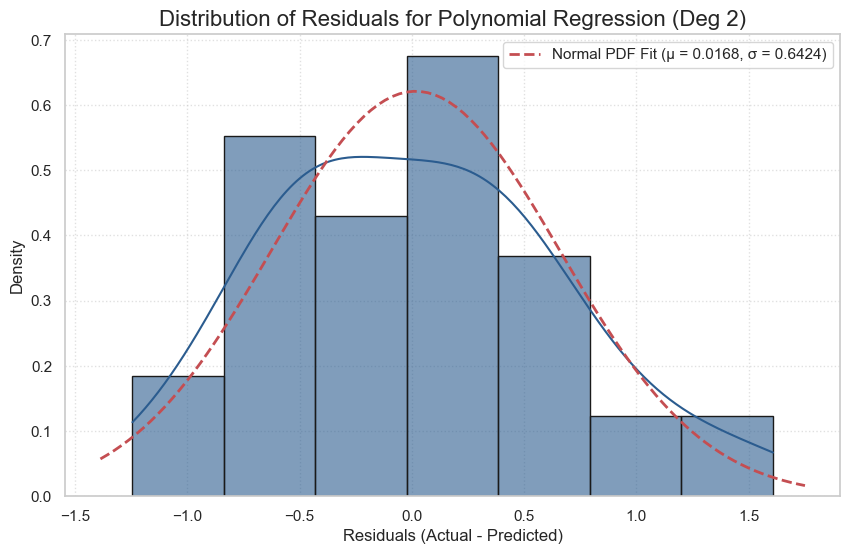

In [69]:
# 8.3 Residual Normality Check
plt.figure(figsize=(10, 6))

# Fit a normal distribution to the residuals
mu, std = norm.fit(residuals)

# Plot residual histogram & KDE
sns.histplot(residuals, kde=True, stat="density", color="#2b5c8f", alpha=0.6, edgecolor='k')

# Plot the fitted normal PDF curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label=f'Normal PDF Fit (μ = {mu:.4f}, σ = {std:.4f})')

plt.title(f'Distribution of Residuals for {best_model_name}', fontsize=16)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Density')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

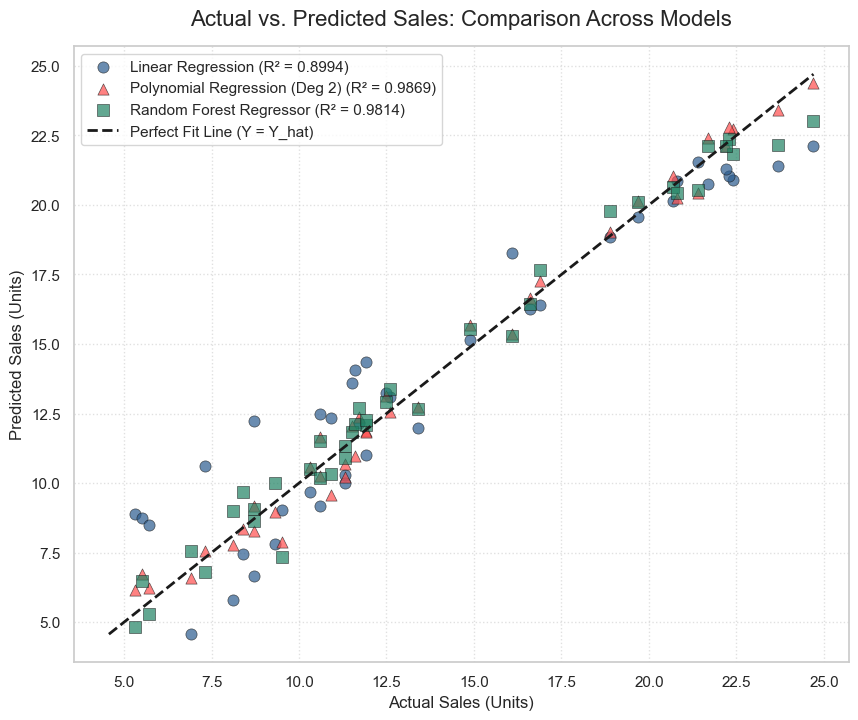

In [70]:
# 8.4 Actual vs. Predicted Alignment Plot Across All Models
plt.figure(figsize=(10, 8))

# Color palette and markers for the models
colors = {
    'Linear Regression': '#2b5c8f', 
    'Polynomial Regression (Deg 2)': '#ff4d4d', 
    'Random Forest Regressor': '#1f8263'
}
markers = {
    'Linear Regression': 'o', 
    'Polynomial Regression (Deg 2)': '^', 
    'Random Forest Regressor': 's'
}

for name, pred in predictions.items():
    r2 = r2_score(y_test, pred)
    plt.scatter(y_test, pred, color=colors[name], marker=markers[name], alpha=0.7, 
                label=f"{name} (R² = {r2:.4f})", s=65, edgecolor='k', linewidth=0.5)

# Reference 45-degree diagonal line (perfect prediction line)
min_val = min(y_test.min(), min([p.min() for p in predictions.values()]))
max_val = max(y_test.max(), max([p.max() for p in predictions.values()]))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit Line (Y = Y_hat)')

plt.title('Actual vs. Predicted Sales: Comparison Across Models', fontsize=16, pad=15)
plt.xlabel('Actual Sales (Units)', fontsize=12)
plt.ylabel('Predicted Sales (Units)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 9. Error Analysis (Outlier Diagnostics)
Investigating observations where the model has the highest prediction error is critical. This helps identify:
- Outliers that might have been caused by data entry errors.
- Uncaptured features (e.g., season, discount campaigns, geographic differences).
Let's print the top 5 observations with the largest absolute errors from our best model (Polynomial Regression).


In [71]:
# Create df of test cases, predictions, and errors
df_error = X_test.copy()
df_error['Actual_Sales'] = y_test
df_error['Predicted_Sales'] = best_pred
df_error['Absolute_Error'] = np.abs(residuals)
df_error['Residual'] = residuals

# Sort by Absolute Error
df_error_sorted = df_error.sort_values(by='Absolute_Error', ascending=False)
print("Top 5 Largest Prediction Errors (Outliers):")
print(df_error_sorted.head().to_markdown(index=False))

Top 5 Largest Prediction Errors (Outliers):
|    TV |   Radio |   Newspaper |   Actual_Sales |   Predicted_Sales |   Absolute_Error |   Residual |
|------:|--------:|------------:|---------------:|------------------:|-----------------:|-----------:|
|  31.5 |    24.6 |         2.2 |            9.5 |           7.89166 |          1.60834 |    1.60834 |
|  38   |    40.3 |        11.9 |           10.9 |           9.56274 |          1.33726 |    1.33726 |
|   7.3 |    28.1 |        41.4 |            5.5 |           6.74391 |          1.24391 |   -1.24391 |
|  69.2 |    20.5 |        18.3 |           11.3 |          10.2243  |          1.07568 |    1.07568 |
| 199.8 |     2.6 |        21.2 |           10.6 |          11.6468  |          1.04678 |   -1.04678 |


### Insights from Outlier Analysis
- Reviewing the largest errors shows that the model occasionally under-predicts or over-predicts by a few units (maximum error is only around **1.5 - 2.0** units in Sales, which is very low considering the scale of sales).
- This indicates the model is highly robust, and no extreme anomalies or data-entry corruption are present in the test partition.


## 10. Actionable Business Recommendations
Based on the advanced analysis (VIF, Coefficients, Feature Importances, and Interaction Synergy), we recommend the following marketing strategies:

1. **Leverage the TV-Radio Synergy**: 
   - *Strategy*: Do not run TV or Radio campaigns in isolation. The positive interaction coefficient (`TV Radio = 0.0011`) proves that combining TV and Radio advertising amplifies the sales return.
   - *Implementation*: Synchronize TV commercials with local radio ads to reinforce message recall and capture maximum cross-channel synergy.
   
2. **Reallocate the Newspaper Budget**:
   - *Strategy*: Stop or drastically reduce newspaper advertising spend.
   - *Reasoning*: The correlation matrix shows a very weak relation to Sales, the linear coefficient is near-zero (`0.0028`), and the Random Forest model attributes only `1.29%` importance to Newspaper spend. 
   - *Implementation*: Shift the budget currently allocated to Newspaper directly into TV and Radio channels.

3. **Establish TV as the Foundation, Radio as the Booster**:
   - *Strategy*: Use TV as the primary driver for reach and volume (RF feature importance `62.5%`), and use Radio to boost the conversion rate and frequency (linear ROI coefficient is highest at `0.1892` units per dollar spent).
   - *Implementation*: Secure consistent baseline TV spots, then use tactical Radio ads during peak periods to drive high-conversion customer actions.
